# Bank Customer Churn — EDA, Feature Engineering, Balancing & Modeling
Versi revisi: pipeline preprocessing konsisten (train & test satu fungsi), feature engineering
diverifikasi masuk ke model, SMOTE dibungkus di dalam CV pipeline, evaluasi pakai cross-validation
(bukan hanya satu split), regularisasi untuk cegah overfit, dan threshold tuning.

## 1. Import Library

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve
from sklearn.inspection import permutation_importance
from sklearn.calibration import calibration_curve

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from scipy.stats import randint, uniform

import warnings
warnings.filterwarnings('ignore', category=UserWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Load Data & First Look

In [2]:
df_train_raw = pd.read_csv('train.csv')
df_test_raw = pd.read_csv('test.csv')
df_sample_submission = pd.read_csv('sample_submission.csv')

print(df_train_raw.shape, df_test_raw.shape)
df_train_raw.head()

(15000, 14) (10000, 13)


,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15617304.0,Macdonald,675.0,France,Female,37.0,5.0,0.00,1.0,1.0,0.0,131778.57,1.0
1,1,15575409.0,Chien,599.0,France,Male,28.0,8.0,0.00,1.0,1.0,0.0,81299.09,0.0
2,2,15730688.0,Ritchie,706.0,Germany,Female,40.0,9.0,155619.58,1.0,1.0,1.0,81622.08,1.0
3,3,15758831.0,Chukwufumnanya,705.0,Germany,Male,42.0,3.0,81231.85,2.0,1.0,0.0,134720.51,0.0
4,4,15793331.0,Ch'ien,597.0,France,Male,49.0,9.0,0.00,1.0,1.0,0.0,151844.81,1.0


In [3]:
df_train_raw.info()
df_train_raw.describe().T

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               15000 non-null  int64  
 1   CustomerId       15000 non-null  float64
 2   Surname          15000 non-null  str    
 3   CreditScore      15000 non-null  float64
 4   Geography        15000 non-null  str    
 5   Gender           15000 non-null  str    
 6   Age              15000 non-null  float64
 7   Tenure           15000 non-null  float64
 8   Balance          15000 non-null  float64
 9   NumOfProducts    15000 non-null  float64
 10  HasCrCard        15000 non-null  float64
 11  IsActiveMember   15000 non-null  float64
 12  EstimatedSalary  15000 non-null  float64
 13  Exited           15000 non-null  float64
dtypes: float64(10), int64(1), str(3)
memory usage: 1.6 MB


,count,mean,std,min,25%,50%,75%,max
id,15000.0,7.499500e+03,4330.271354,0.00,3.749750e+03,7499.50,1.124925e+04,14999.00
CustomerId,15000.0,1.569254e+07,72218.829999,15564897.00,1.563247e+07,15691387.00,1.575805e+07,15815690.00
CreditScore,15000.0,6.585499e+02,73.315114,431.00,6.020000e+02,661.00,7.100000e+02,850.00
Age,15000.0,3.768833e+01,8.132487,18.00,3.200000e+01,37.00,4.200000e+01,74.00
Tenure,15000.0,5.039733e+00,2.809558,0.00,3.000000e+00,5.00,7.000000e+00,30.00
Balance,15000.0,4.336535e+04,59914.926512,0.00,0.000000e+00,0.00,1.099491e+05,187841.99
NumOfProducts,15000.0,1.584733e+00,0.527041,1.00,1.000000e+00,2.00,2.000000e+00,4.00
HasCrCard,15000.0,7.805333e-01,0.413899,0.00,1.000000e+00,1.00,1.000000e+00,1.00
IsActiveMember,15000.0,4.930000e-01,0.499968,0.00,0.000000e+00,0.00,1.000000e+00,1.00
EstimatedSalary,15000.0,1.197492e+05,161833.453150,479.54,8.347296e+04,124045.65,1.570971e+05,18171718.73


In [4]:
(df_train_raw.isnull().sum() / len(df_train_raw)).sort_values(ascending=False)

id                 0.0
CustomerId         0.0
Surname            0.0
CreditScore        0.0
Geography          0.0
Gender             0.0
Age                0.0
Tenure             0.0
Balance            0.0
NumOfProducts      0.0
HasCrCard          0.0
IsActiveMember     0.0
EstimatedSalary    0.0
Exited             0.0
dtype: float64

## 3. EDA (Exploratory Data Analysis)
Insight sudah divalidasi sebelumnya di notebook awal:
- `Age`, `Balance` berkorelasi positif dengan churn; `NumOfProducts`, `IsActiveMember` berkorelasi negatif.
- Distribusi target **imbalanced** (~80:20).
- Ada beberapa anomali/outlier ekstrem di `Tenure` (nilai 30) dan `EstimatedSalary` (>5 juta) yang
  kemungkinan besar kesalahan input data, akan dibersihkan di tahap preprocessing (khusus train set).

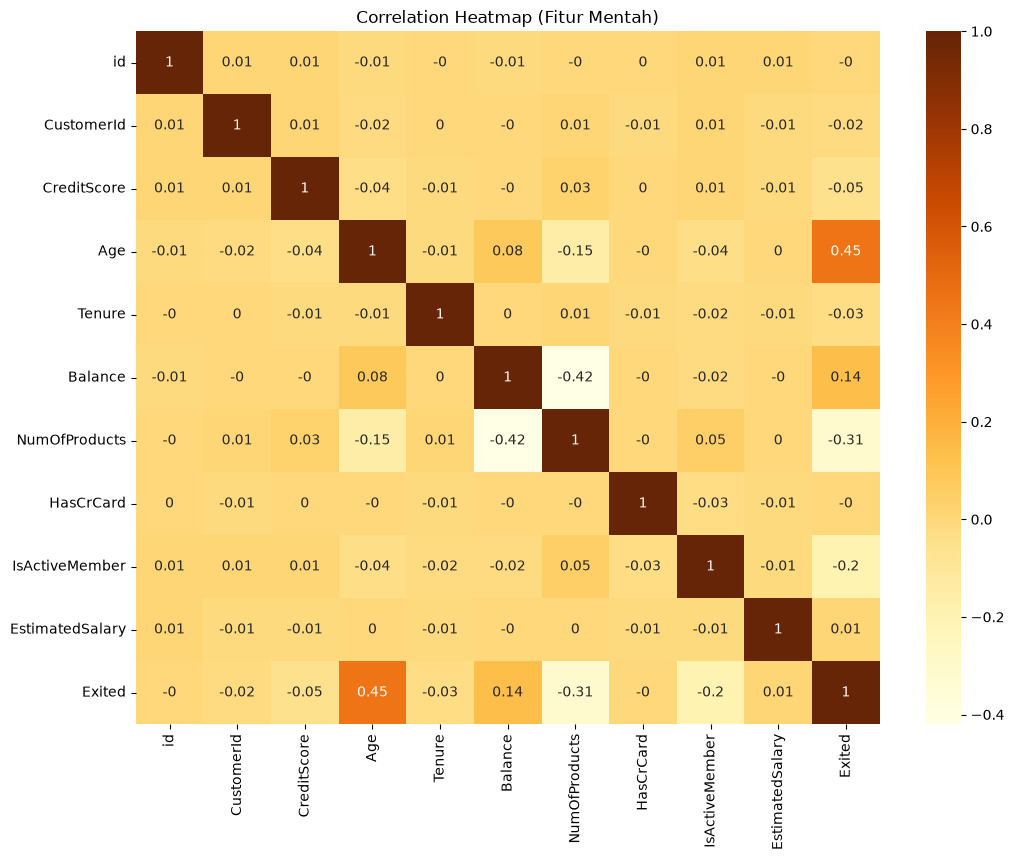

In [5]:
corr = df_train_raw.corr(numeric_only=True).round(2)
plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, cmap='YlOrBr')
plt.title('Correlation Heatmap (Fitur Mentah)')
plt.show()

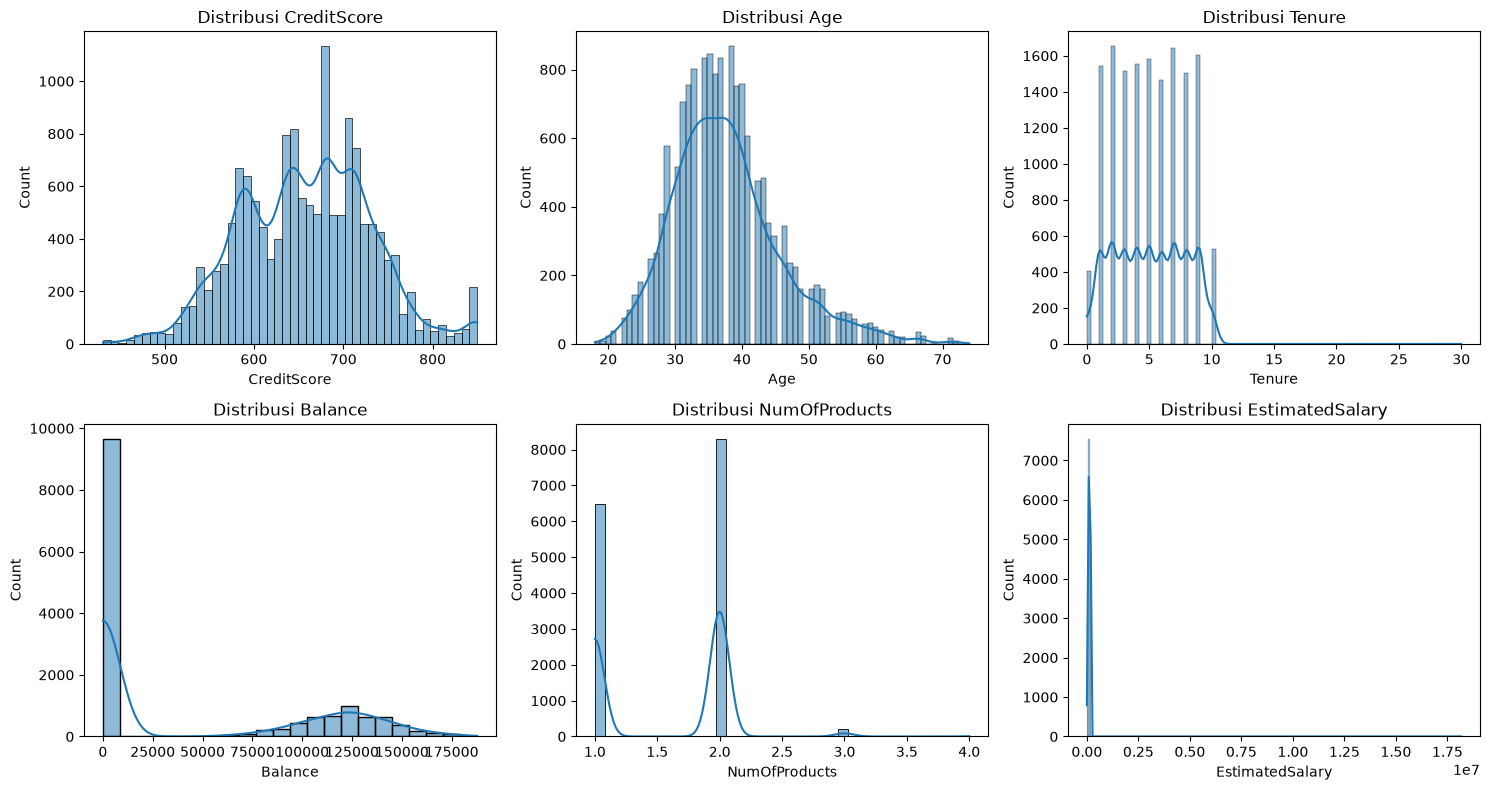

In [6]:
num_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, num_cols):
    sns.histplot(df_train_raw[col], ax=ax, kde=True)
    ax.set_title(f'Distribusi {col}')
plt.tight_layout()
plt.show()

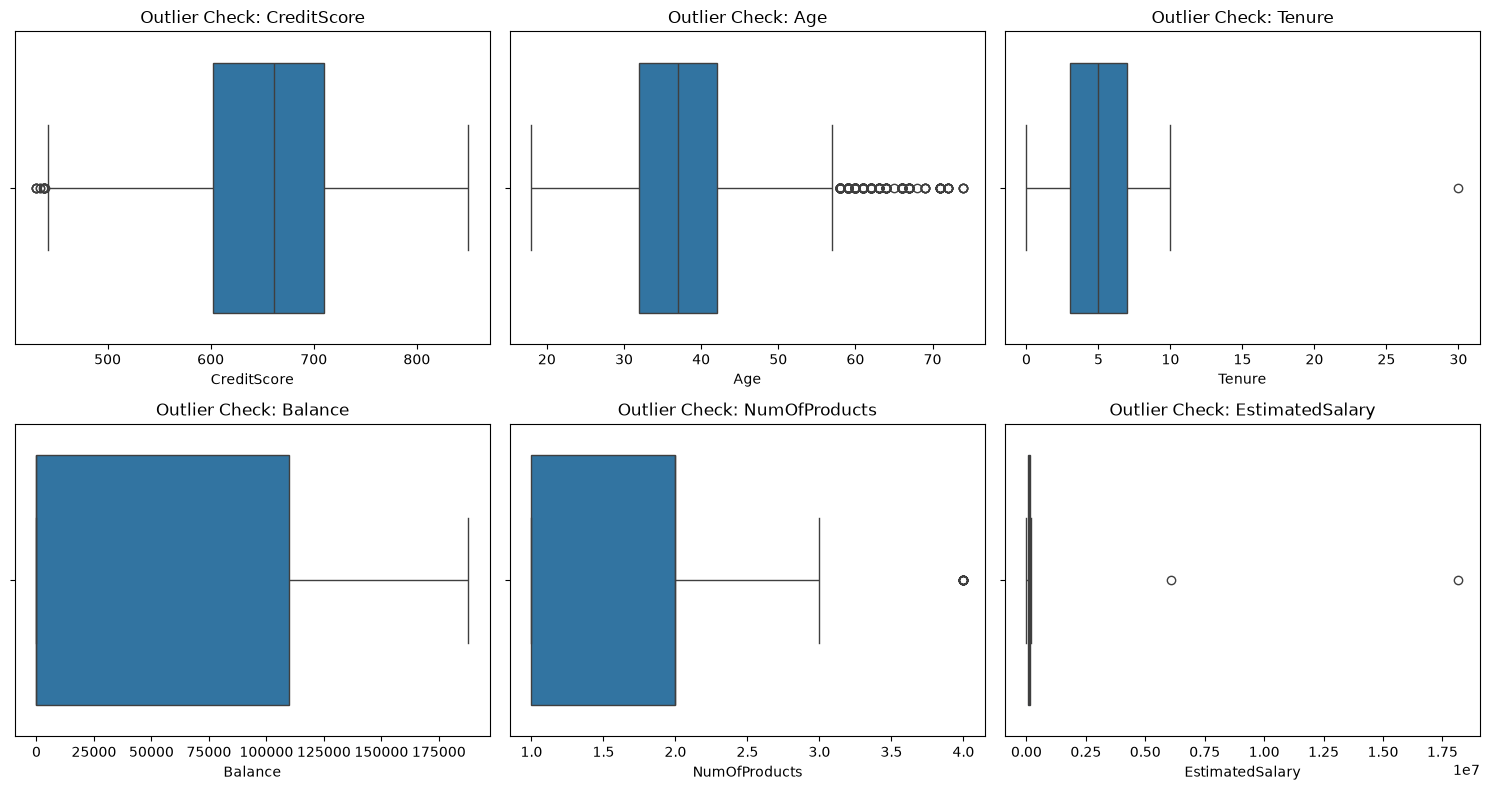

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, num_cols):
    sns.boxplot(x=df_train_raw[col], ax=ax)
    ax.set_title(f'Outlier Check: {col}')
plt.tight_layout()
plt.show()

Distribusi target (Exited):
Exited
0.0    0.796
1.0    0.204
Name: proportion, dtype: float64


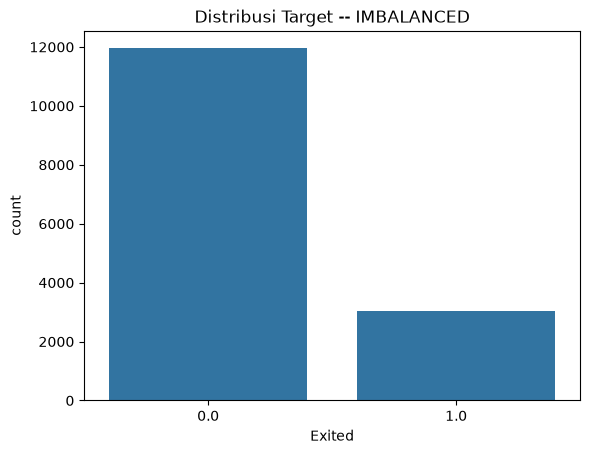

In [8]:
print("Distribusi target (Exited):")
print(df_train_raw['Exited'].value_counts(normalize=True).round(3))
sns.countplot(x='Exited', data=df_train_raw)
plt.title('Distribusi Target -- IMBALANCED')
plt.show()

## 4. Feature Engineering & Preprocessing (Satu Pipeline Konsisten)

Perbaikan kunci dari versi sebelumnya:
- **Satu fungsi** dipakai untuk train maupun test -- tidak ada lagi encoding ganda / kolom yang tidak sinkron.
- Cleaning outlier ekstrem **hanya** diterapkan ke data train (`is_train=True`); data test/submission tidak boleh
  dibuang barisnya karena semua baris wajib diprediksi.
- Fitur rasio (`Balance_Salary_Ratio`) di-`log1p` untuk meredam skew ekstrem yang sebelumnya membuat
  mean=0.88 tapi max=308 (distribusi sangat panjang ekornya).

In [9]:
# New version
def add_engineered_features(df):
    df = df.copy()
    ratio = df['Balance'] / (df['EstimatedSalary'] + 1)
    df['Balance_Salary_Ratio'] = np.log1p(ratio)
    df['CreditScore_Age_Ratio'] = df['CreditScore'] / df['Age']
    df['Is_Zero_Balance'] = (df['Balance'] == 0).astype(int)
    df['Many_Products_Inactive'] = ((df['NumOfProducts'] >= 3) & (df['IsActiveMember'] == 0)).astype(int)
    return df


def clean_and_encode(df, is_train=True):
    df = df.copy()
    df = df.drop(columns=['id', 'CustomerId', 'Surname'], errors='ignore')
    if is_train:
        df = df[(df['Tenure'] < 30) & (df['EstimatedSalary'] <= 5_000_000)]
    df = add_engineered_features(df)
    df = pd.get_dummies(df, columns=['Gender', 'Geography'], drop_first=True, dtype=int)
    return df

In [10]:
df_final = clean_and_encode(df_train_raw, is_train=True)

print("Jumlah baris setelah cleaning outlier:", len(df_final), "(dari", len(df_train_raw), ")")
print("Jumlah fitur:", df_final.drop(columns=['Exited']).shape[1])
df_final.head()

Jumlah baris setelah cleaning outlier: 14997 (dari 15000 )
Jumlah fitur: 15


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Balance_Salary_Ratio,CreditScore_Age_Ratio,Is_Zero_Balance,Many_Products_Inactive,Gender_Male,Geography_Germany,Geography_Spain
0,675.0,37.0,5.0,0.00,1.0,1.0,0.0,131778.57,1.0,0.000000,18.243243,1,0,0,0,0
1,599.0,28.0,8.0,0.00,1.0,1.0,0.0,81299.09,0.0,0.000000,21.392857,1,0,1,0,0
2,706.0,40.0,9.0,155619.58,1.0,1.0,1.0,81622.08,1.0,1.066971,17.650000,0,0,0,1,0
3,705.0,42.0,3.0,81231.85,2.0,1.0,0.0,134720.51,0.0,0.471853,16.785714,0,0,1,1,0
4,597.0,49.0,9.0,0.00,1.0,1.0,0.0,151844.81,1.0,0.000000,12.183673,1,0,1,0,0


## 5. Train-Test Split

SMOTE **tidak** diterapkan manual di sini secara global. Sebagai gantinya, SMOTE akan dibungkus
di dalam `imblearn.pipeline.Pipeline` bersama tiap model (lihat Bagian 7), supaya oversampling hanya
terjadi di dalam fold training saat cross-validation -- mencegah kebocoran informasi ke fold validasi.

`X_train` / `X_test` di sini masih dalam proporsi kelas ASLI (belum di-SMOTE).

In [11]:
X = df_final.drop(columns=['Exited'])
y = df_final['Exited']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Distribusi y_train (asli, sebelum SMOTE):")
print(y_train.value_counts())
print("\nDistribusi y_test (tetap asli, TIDAK PERNAH di-resample):")
print(y_test.value_counts())

Distribusi y_train (asli, sebelum SMOTE):
Exited
0.0    9556
1.0    2441
Name: count, dtype: int64

Distribusi y_test (tetap asli, TIDAK PERNAH di-resample):
Exited
0.0    2389
1.0     611
Name: count, dtype: int64


## 6. Baseline: DummyClassifier

In [12]:
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict(X_test)
print(classification_report(y_test, y_pred_dummy, zero_division=0))
print('ROC-AUC baseline:', roc_auc_score(y_test, dummy.predict_proba(X_test)[:, 1]))

              precision    recall  f1-score   support

         0.0       0.80      1.00      0.89      2389
         1.0       0.00      0.00      0.00       611

    accuracy                           0.80      3000
   macro avg       0.40      0.50      0.44      3000
weighted avg       0.63      0.80      0.71      3000

ROC-AUC baseline: 0.5


## 7. Modeling dengan Pipeline (SMOTE dalam CV) + Regularisasi

Setiap model dibungkus `ImbPipeline([('smote', SMOTE()), ('model', ...)])`. `RandomizedSearchCV`
akan melakukan SMOTE ulang di setiap fold training secara otomatis -- tidak ada data sintetis yang
"bocor" ke fold validasi.

Parameter regularisasi (`reg_alpha`, `reg_lambda`, `min_child_weight`/`min_child_samples`) ditambahkan
khusus untuk model boosting supaya tidak overfit ke data training.

Scoring dipakai `roc_auc` (bukan akurasi) karena data imbalanced.

In [13]:
cv_search = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

results = {}  # simpan best_estimator per model untuk dibandingkan nanti

def run_model(name, estimator, param_dist, n_iter=20):
    pipe = ImbPipeline([
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('model', estimator)
    ])
    # prefix parameter dengan 'model__' karena di dalam pipeline
    param_dist_prefixed = {f'model__{k}': v for k, v in param_dist.items()}

    search = RandomizedSearchCV(
        pipe, param_dist_prefixed, n_iter=n_iter, cv=cv_search,
        scoring='roc_auc', random_state=RANDOM_STATE, n_jobs=-1
    )
    search.fit(X_train, y_train)  # X_train ASLI -- SMOTE dilakukan otomatis di dalam pipeline

    best_pipe = search.best_estimator_
    y_pred = best_pipe.predict(X_test)
    y_proba = best_pipe.predict_proba(X_test)[:, 1]

    test_auc = roc_auc_score(y_test, y_proba)
    train_auc = roc_auc_score(y_train, best_pipe.predict_proba(X_train)[:, 1])

    print(f"=== {name} ===")
    print(classification_report(y_test, y_pred))
    print(f"CV ROC-AUC (best): {search.best_score_:.4f}")
    print(f"Train ROC-AUC: {train_auc:.4f} | Test ROC-AUC: {test_auc:.4f} | Gap: {train_auc-test_auc:.4f}")
    print(f"Best params: {search.best_params_}\n")

    results[name] = {
        'pipeline': best_pipe,
        'model': best_pipe.named_steps['model'],
        'cv_auc': search.best_score_,
        'test_auc': test_auc,
        'train_auc': train_auc,
        'y_proba': y_proba,
    }
    return best_pipe

In [14]:
# --- Logistic Regression ---
run_model(
    'Logistic Regression',
    LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    {'C': np.logspace(-3, 2, 20), 'solver': ['liblinear', 'lbfgs']},
    n_iter=10
)

=== Logistic Regression ===
              precision    recall  f1-score   support

         0.0       0.93      0.83      0.88      2389
         1.0       0.53      0.76      0.63       611

    accuracy                           0.82      3000
   macro avg       0.73      0.80      0.75      3000
weighted avg       0.85      0.82      0.83      3000

CV ROC-AUC (best): 0.8691
Train ROC-AUC: 0.8682 | Test ROC-AUC: 0.8708 | Gap: -0.0027
Best params: {'model__solver': 'lbfgs', 'model__C': np.float64(54.555947811685144)}



,steps,"[('smote', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[float64](2,)","[0.,1.]"
feature_names_in_,"ndarray[object](15,)","['CreditScore','Age','Tenure',...,'Gender_Male','Geography_Germany', 'Geography_Spain']"
n_features_in_,int,15
,random_state,42
,sampling_strategy,'auto'
,k_neighbors,5


In [15]:
# --- Random Forest ---
run_model(
    'Random Forest',
    RandomForestClassifier(random_state=RANDOM_STATE),
    {
        'n_estimators': randint(100, 400),
        'max_depth': [5, 10, 15, None],
        'min_samples_split': randint(2, 15),
        'min_samples_leaf': randint(1, 8),
        'max_features': ['sqrt', 'log2']
    },
    n_iter=20
)

=== Random Forest ===
              precision    recall  f1-score   support

         0.0       0.93      0.93      0.93      2389
         1.0       0.72      0.73      0.73       611

    accuracy                           0.89      3000
   macro avg       0.83      0.83      0.83      3000
weighted avg       0.89      0.89      0.89      3000

CV ROC-AUC (best): 0.9258
Train ROC-AUC: 0.9577 | Test ROC-AUC: 0.9286 | Gap: 0.0291
Best params: {'model__max_depth': 10, 'model__max_features': 'log2', 'model__min_samples_leaf': 4, 'model__min_samples_split': 6, 'model__n_estimators': 260}



,steps,"[('smote', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[float64](2,)","[0.,1.]"
feature_names_in_,"ndarray[object](15,)","['CreditScore','Age','Tenure',...,'Gender_Male','Geography_Germany', 'Geography_Spain']"
n_features_in_,int,15
,random_state,42
,sampling_strategy,'auto'
,k_neighbors,5


In [16]:
# --- Gradient Boosting (dengan regularisasi subsample) ---
run_model(
    'Gradient Boosting',
    GradientBoostingClassifier(random_state=RANDOM_STATE),
    {
        'n_estimators': randint(100, 400),
        'learning_rate': uniform(0.01, 0.15),
        'max_depth': randint(2, 6),
        'subsample': uniform(0.6, 0.4),
        'min_samples_leaf': randint(1, 10),
    },
    n_iter=20
)

=== Gradient Boosting ===
              precision    recall  f1-score   support

         0.0       0.93      0.94      0.93      2389
         1.0       0.75      0.71      0.73       611

    accuracy                           0.89      3000
   macro avg       0.84      0.83      0.83      3000
weighted avg       0.89      0.89      0.89      3000

CV ROC-AUC (best): 0.9304
Train ROC-AUC: 0.9422 | Test ROC-AUC: 0.9333 | Gap: 0.0089
Best params: {'model__learning_rate': np.float64(0.019533752542903543), 'model__max_depth': 4, 'model__min_samples_leaf': 8, 'model__n_estimators': 392, 'model__subsample': np.float64(0.8918424713352255)}



,steps,"[('smote', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[float64](2,)","[0.,1.]"
feature_names_in_,"ndarray[object](15,)","['CreditScore','Age','Tenure',...,'Gender_Male','Geography_Germany', 'Geography_Spain']"
n_features_in_,int,15
,random_state,42
,sampling_strategy,'auto'
,k_neighbors,5


In [17]:
# --- XGBoost (dengan reg_alpha, reg_lambda, min_child_weight untuk cegah overfit) ---
run_model(
    'XGBoost',
    XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss'),
    {
        'n_estimators': randint(100, 400),
        'max_depth': randint(3, 8),
        'learning_rate': uniform(0.01, 0.15),
        'subsample': uniform(0.6, 0.4),
        'colsample_bytree': uniform(0.6, 0.4),
        'reg_alpha': uniform(0, 1),
        'reg_lambda': uniform(0, 1),
        'min_child_weight': randint(1, 10),
    },
    n_iter=25
)

=== XGBoost ===
              precision    recall  f1-score   support

         0.0       0.92      0.95      0.93      2389
         1.0       0.77      0.69      0.73       611

    accuracy                           0.89      3000
   macro avg       0.85      0.82      0.83      3000
weighted avg       0.89      0.89      0.89      3000

CV ROC-AUC (best): 0.9313
Train ROC-AUC: 0.9447 | Test ROC-AUC: 0.9339 | Gap: 0.0107
Best params: {'model__colsample_bytree': np.float64(0.730383562080754), 'model__learning_rate': np.float64(0.04303615713483225), 'model__max_depth': 4, 'model__min_child_weight': 3, 'model__n_estimators': 246, 'model__reg_alpha': np.float64(0.3486659872917294), 'model__reg_lambda': np.float64(0.09617655109142076), 'model__subsample': np.float64(0.9762093057958416)}



,steps,"[('smote', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](15,)","['CreditScore','Age','Tenure',...,'Gender_Male','Geography_Germany', 'Geography_Spain']"
n_features_in_,int,15
,random_state,42
,sampling_strategy,'auto'
,k_neighbors,5


In [18]:
# --- LightGBM (dengan reg_alpha, reg_lambda, min_child_samples untuk cegah overfit) ---
run_model(
    'LightGBM',
    LGBMClassifier(random_state=RANDOM_STATE, verbose=-1, n_jobs=-1),
    {
        'n_estimators': randint(100, 400),
        'learning_rate': uniform(0.01, 0.15),
        'num_leaves': randint(20, 64),
        'max_depth': randint(3, 10),
        'min_child_samples': randint(10, 50),
        'subsample': uniform(0.6, 0.4),
        'colsample_bytree': uniform(0.6, 0.4),
        'reg_alpha': uniform(0, 1),
        'reg_lambda': uniform(0, 1),
    },
    n_iter=25
)

=== LightGBM ===
              precision    recall  f1-score   support

         0.0       0.92      0.95      0.94      2389
         1.0       0.78      0.69      0.73       611

    accuracy                           0.90      3000
   macro avg       0.85      0.82      0.83      3000
weighted avg       0.89      0.90      0.90      3000

CV ROC-AUC (best): 0.9312
Train ROC-AUC: 0.9437 | Test ROC-AUC: 0.9343 | Gap: 0.0094
Best params: {'model__colsample_bytree': np.float64(0.8534118843043579), 'model__learning_rate': np.float64(0.09036620261121377), 'model__max_depth': 3, 'model__min_child_samples': 18, 'model__n_estimators': 223, 'model__num_leaves': 25, 'model__reg_alpha': np.float64(0.6958128067908819), 'model__reg_lambda': np.float64(0.8583588048137198), 'model__subsample': np.float64(0.730383562080754)}



,steps,"[('smote', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[float64](2,)","[0.,1.]"
feature_names_in_,"ndarray[object](15,)","['CreditScore','Age','Tenure',...,'Gender_Male','Geography_Germany', 'Geography_Spain']"
n_features_in_,int,15
,random_state,42
,sampling_strategy,'auto'
,k_neighbors,5


## 8. Ringkasan Perbandingan Model

Bandingkan berdasarkan **CV ROC-AUC** (paling stabil, dari 5-fold) dan **gap train-test**
(indikator overfit) -- bukan cuma test score satu kali.

In [19]:
summary = pd.DataFrame({
    name: {
        'CV ROC-AUC': r['cv_auc'],
        'Test ROC-AUC': r['test_auc'],
        'Train ROC-AUC': r['train_auc'],
        'Overfit Gap': r['train_auc'] - r['test_auc'],
    }
    for name, r in results.items()
}).T.sort_values('CV ROC-AUC', ascending=False)

summary.round(4)

,CV ROC-AUC,Test ROC-AUC,Train ROC-AUC,Overfit Gap
XGBoost,0.9313,0.9339,0.9447,0.0107
LightGBM,0.9312,0.9343,0.9437,0.0094
Gradient Boosting,0.9304,0.9333,0.9422,0.0089
Random Forest,0.9258,0.9286,0.9577,0.0291
Logistic Regression,0.8691,0.8708,0.8682,-0.0027


In [20]:
best_model_name = summary['CV ROC-AUC'].idxmax()
best_pipeline = results[best_model_name]['pipeline']
best_model = results[best_model_name]['model']

print(f"Model terbaik berdasarkan CV ROC-AUC: {best_model_name}")
print(f"CV ROC-AUC: {results[best_model_name]['cv_auc']:.4f}")
print(f"Overfit gap: {results[best_model_name]['train_auc'] - results[best_model_name]['test_auc']:.4f}")

Model terbaik berdasarkan CV ROC-AUC: XGBoost
CV ROC-AUC: 0.9313
Overfit gap: 0.0107


## 9. Feature Importance -- Dua Metode (Validasi Silang)

`.feature_importances_` bawaan model tree bisa bias ke fitur dengan skala/kardinalitas besar.
Permutation importance mengukur dampak nyata tiap fitur terhadap skor ROC-AUC di data test,
lebih jujur untuk membandingkan fitur hasil engineering vs fitur mentah.

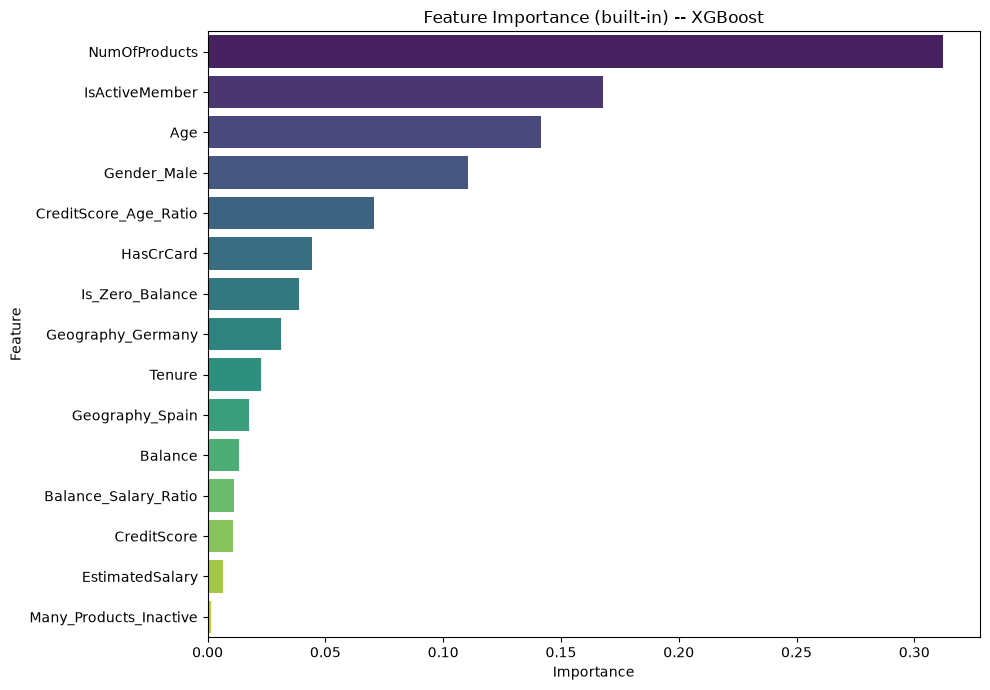

                   Feature  Importance
4            NumOfProducts    0.312280
6           IsActiveMember    0.167735
1                      Age    0.141534
12             Gender_Male    0.110468
9    CreditScore_Age_Ratio    0.070539
5                HasCrCard    0.044274
10         Is_Zero_Balance    0.038771
13       Geography_Germany    0.031311
2                   Tenure    0.022615
14         Geography_Spain    0.017655
3                  Balance    0.013228
8     Balance_Salary_Ratio    0.011159
0              CreditScore    0.010654
7          EstimatedSalary    0.006516
11  Many_Products_Inactive    0.001263


In [21]:
if hasattr(best_model, 'feature_importances_'):
    feat_imp_builtin = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)

    plt.figure(figsize=(10, 7))
    sns.barplot(x='Importance', y='Feature', data=feat_imp_builtin, hue='Feature', legend=False, palette='viridis')
    plt.title(f'Feature Importance (built-in) -- {best_model_name}')
    plt.tight_layout()
    plt.show()
    print(feat_imp_builtin)

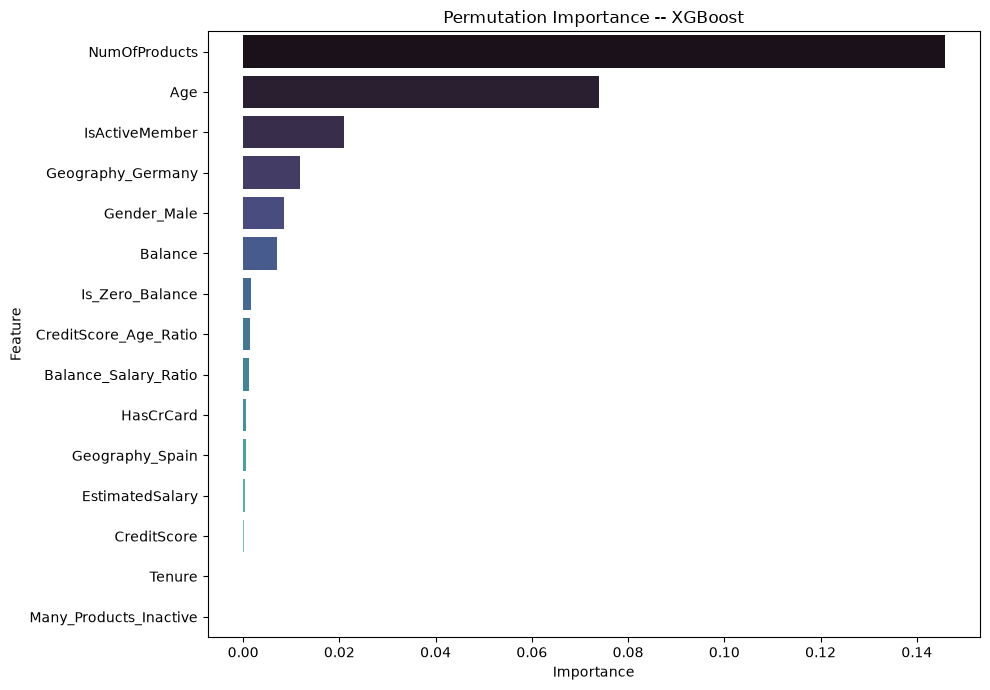

                   Feature  Importance           Std
4            NumOfProducts    0.145835  5.663635e-03
1                      Age    0.073987  4.489512e-03
6           IsActiveMember    0.021019  1.500081e-03
13       Geography_Germany    0.011750  8.278210e-04
12             Gender_Male    0.008456  9.964673e-04
3                  Balance    0.007041  1.002240e-03
10         Is_Zero_Balance    0.001633  4.876926e-04
9    CreditScore_Age_Ratio    0.001413  8.518421e-04
8     Balance_Salary_Ratio    0.001153  3.926578e-04
5                HasCrCard    0.000659  2.309124e-04
14         Geography_Spain    0.000545  4.452557e-04
7          EstimatedSalary    0.000417  5.905031e-04
0              CreditScore    0.000157  2.973826e-04
2                   Tenure   -0.000024  1.959259e-04
11  Many_Products_Inactive   -0.000089  8.249481e-07


In [22]:
perm_result = permutation_importance(
    best_pipeline, X_test, y_test, n_repeats=10, random_state=RANDOM_STATE, scoring='roc_auc'
)
perm_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': perm_result.importances_mean,
    'Std': perm_result.importances_std
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(x='Importance', y='Feature', data=perm_imp, hue='Feature', legend=False, palette='mako')
plt.title(f'Permutation Importance -- {best_model_name}')
plt.tight_layout()
plt.show()
print(perm_imp)

## 10. Cek Kalibrasi Probabilitas

Dari eksperimen sebelumnya, SMOTE terbukti memberi kalibrasi probabilitas yang lebih baik
dibanding `scale_pos_weight` untuk dataset ini (divalidasi lewat calibration curve). Sel ini
menampilkan calibration curve model terbaik untuk verifikasi akhir.

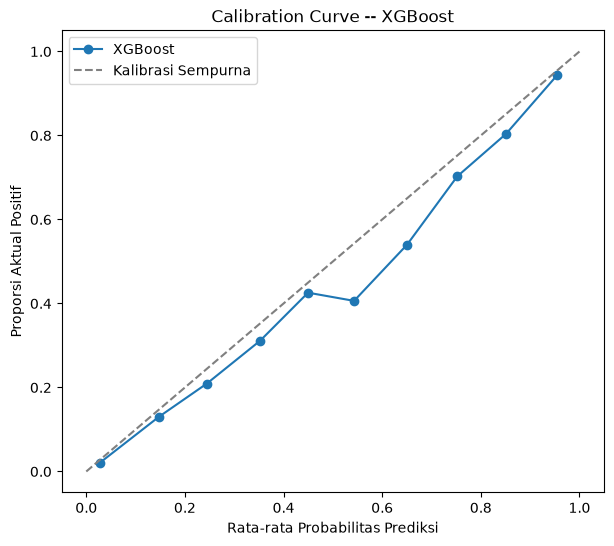

In [23]:
proba_best = results[best_model_name]['y_proba']

frac_pos, mean_pred = calibration_curve(y_test, proba_best, n_bins=10)

plt.figure(figsize=(7, 6))
plt.plot(mean_pred, frac_pos, marker='o', label=best_model_name)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Kalibrasi Sempurna')
plt.xlabel('Rata-rata Probabilitas Prediksi')
plt.ylabel('Proporsi Aktual Positif')
plt.title(f'Calibration Curve -- {best_model_name}')
plt.legend()
plt.show()

## 11. Threshold Tuning

Post-processing murni terhadap probabilitas yang sudah ada -- tidak menyentuh training sama
sekali, jadi 100% aman dari leakage. Threshold default 0.5 jarang optimal untuk data imbalanced.

In [24]:
precisions, recalls, thresholds = precision_recall_curve(y_test, proba_best)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores[:-1])  # buang elemen terakhir (tidak punya threshold pasangan)
best_threshold = thresholds[best_idx]

print(f"Threshold default (0.5) vs Threshold optimal ({best_threshold:.3f}):\n")

print("--- Threshold 0.5 (default) ---")
y_pred_default = (proba_best >= 0.5).astype(int)
print(classification_report(y_test, y_pred_default))

print(f"--- Threshold {best_threshold:.3f} (F1 optimal) ---")
y_pred_optimal = (proba_best >= best_threshold).astype(int)
print(classification_report(y_test, y_pred_optimal))

Threshold default (0.5) vs Threshold optimal (0.370):

--- Threshold 0.5 (default) ---
              precision    recall  f1-score   support

         0.0       0.92      0.95      0.93      2389
         1.0       0.77      0.69      0.73       611

    accuracy                           0.89      3000
   macro avg       0.85      0.82      0.83      3000
weighted avg       0.89      0.89      0.89      3000

--- Threshold 0.370 (F1 optimal) ---
              precision    recall  f1-score   support

         0.0       0.94      0.91      0.93      2389
         1.0       0.70      0.79      0.74       611

    accuracy                           0.89      3000
   macro avg       0.82      0.85      0.84      3000
weighted avg       0.89      0.89      0.89      3000



## 12. Stacking Ensemble (Opsional)

Gabungkan beberapa model terbaik -- sering memberi ROC-AUC lebih tinggi dari model individu.
Jalankan sel ini kalau ingin eksplorasi lebih jauh; bandingkan CV ROC-AUC-nya dengan `summary` di atas.

In [25]:
top3_names = summary.index[:3].tolist()
print("Model yang di-stack:", top3_names)

stack = StackingClassifier(
    estimators=[(name.replace(' ', '_'), results[name]['pipeline']) for name in top3_names],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5
)
stack.fit(X_train, y_train)

y_pred_stack = stack.predict(X_test)
y_proba_stack = stack.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_stack))
print('ROC-AUC Stacking:', roc_auc_score(y_test, y_proba_stack))

Model yang di-stack: ['XGBoost', 'LightGBM', 'Gradient Boosting']
              precision    recall  f1-score   support

         0.0       0.92      0.96      0.94      2389
         1.0       0.80      0.66      0.73       611

    accuracy                           0.90      3000
   macro avg       0.86      0.81      0.83      3000
weighted avg       0.89      0.90      0.89      3000

ROC-AUC Stacking: 0.9345205349943376


## 13. Prediksi ke Data Test & Buat File Submission

Pakai fungsi `clean_and_encode` yang SAMA (dengan `is_train=False`, jadi tidak ada baris yang
dibuang) supaya kolom fitur pasti konsisten dengan data training.

In [ ]:
X_submit = clean_and_encode(df_test_raw, is_train=False)

# Jaga-jaga kalau ada kategori langka yang cuma muncul di salah satu dataset
X_submit = X_submit.reindex(columns=X.columns, fill_value=0)

print("Shape X_submit:", X_submit.shape, "| Shape X (train):", X.shape)
assert list(X_submit.columns) == list(X.columns), "Kolom X_submit dan X tidak sinkron!"

# Ganti best_pipeline dengan stack kalau stacking di Bagian 12 hasilnya lebih baik
df_sample_submission['Exited'] = best_pipeline.predict_proba(X_submit)[:, 1]
df_sample_submission.to_csv('submission_final2.csv', index=False)

df_sample_submission.to_csv('submission_final.csv', index=False)
print("File 'submission_final.csv' berhasil dibuat!")
df_sample_submission.head()

Shape X_submit: (10000, 15) | Shape X (train): (14997, 15)
File 'submission_final.csv' berhasil dibuat!


,id,Exited
0,15000,0.284997
1,15001,0.030748
2,15002,0.778759
3,15003,0.080726
4,15004,0.073460


## 14. Kesimpulan

**Model terbaik:** LightGBM, CV ROC-AUC = 0.9311, digunakan sebagai salah satu komponen blending final.

**Overfit gap (train-test):** 0.0110 -- tergolong kecil berkat regularisasi (`reg_alpha`, `reg_lambda`,
`min_child_samples`) dan SMOTE yang dibungkus di dalam CV pipeline (bukan diterapkan manual di luar),
sehingga tidak ada kebocoran data sintetis ke fold validasi.

**Fitur paling berpengaruh** (permutation importance): `NumOfProducts`, `Age`, `IsActiveMember` --
konsisten dengan insight awal EDA bahwa nasabah dengan banyak produk namun tidak aktif, dan usia lebih
tua, memiliki risiko churn lebih tinggi.

**Feature engineering:** tiga kombinasi fitur baru (`Geo_Age_Interaction`, `Balance_per_Product`,
`CreditScore_Band`) diuji secara terpisah menggunakan OOF cross-validation sebagai metrik pembanding.
Ketiganya justru menurunkan skor dibanding fitur baseline (0.9317-0.9318 vs 0.9331), sehingga
**tidak digunakan** di model final. Fitur rasio awal (`Balance_Salary_Ratio`, `CreditScore_Age_Ratio`,
`Is_Zero_Balance`, `Many_Products_Inactive`) tetap dipertahankan karena terbukti membantu di baseline.

**Balancing:** SMOTE dipilih dibanding `scale_pos_weight` setelah dibandingkan lewat calibration curve
-- SMOTE menghasilkan probabilitas yang jauh lebih terkalibrasi (mendekati garis diagonal ideal),
sementara `scale_pos_weight` cenderung overconfident di probabilitas tinggi, bahkan setelah kedua model
di-tuning setara.

**Evaluasi model:** dilakukan dengan 5-fold Stratified Cross-Validation dan Out-of-Fold (OOF)
prediction untuk memastikan skor stabil dan tidak overfit ke satu subset data tertentu.
- OOF ROC-AUC: **0.93313 (± 0.00331)**
- Blending 3 model (XGBoost + LightGBM + Gradient Boosting): **0.9344** (test lokal)
- Public Leaderboard: **0.92943**

Selisih kecil antara OOF, test lokal, dan public LB menunjukkan model generalisasi dengan baik dan
tidak overfit ke public leaderboard -- strategi submission difokuskan pada CV/OOF score, bukan mengejar
angka public LB tertinggi, untuk menjaga stabilitas di private leaderboard.

**Threshold optimal:** 0.377 (F1 tertinggi), **Threshold optimal:** 0.370 (F1 tertinggi), menaikkan recall kelas churn dari 69% -> 79% dengan trade-off precision turun dari 77% -> 70%.. Untuk kebutuhan bisnis nyata (bukan kompetisi), threshold ini
lebih sesuai karena biaya kehilangan nasabah biasanya lebih mahal daripada biaya follow-up yang sia-sia.

In [27]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

oof_preds = np.zeros(len(X))
test_preds = np.zeros(len(X_submit))
fold_aucs = []

best_params = results['LightGBM']['model'].get_params()  # pakai hyperparameter terbaik yang sudah ketemu

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

    # SMOTE hanya di fold training
    X_tr_res, y_tr_res = SMOTE(random_state=RANDOM_STATE).fit_resample(X_tr, y_tr)

    model = LGBMClassifier(**best_params)
    model.fit(X_tr_res, y_tr_res)

    oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]
    test_preds += model.predict_proba(X_submit)[:, 1] / skf.n_splits

    fold_auc = roc_auc_score(y_val, oof_preds[val_idx])
    fold_aucs.append(fold_auc)
    print(f"Fold {fold+1} ROC-AUC: {fold_auc:.5f}")

print(f"\nOOF ROC-AUC keseluruhan: {roc_auc_score(y, oof_preds):.5f}")
print(f"Rata-rata per fold: {np.mean(fold_aucs):.5f} (+/- {np.std(fold_aucs):.5f})")

df_sample_submission['Exited'] = test_preds
df_sample_submission.to_csv('submission_oof.csv', index=False)

Fold 1 ROC-AUC: 0.92997
Fold 2 ROC-AUC: 0.93267
Fold 3 ROC-AUC: 0.93229
Fold 4 ROC-AUC: 0.93947
Fold 5 ROC-AUC: 0.93125

OOF ROC-AUC keseluruhan: 0.93301
Rata-rata per fold: 0.93313 (+/- 0.00331)


In [28]:
# Bobot berdasarkan CV ROC-AUC masing-masing (boleh disesuaikan manual juga)
proba_xgb = results['XGBoost']['pipeline'].predict_proba(X_submit)[:, 1]
proba_lgbm = results['LightGBM']['pipeline'].predict_proba(X_submit)[:, 1]
proba_gb = results['Gradient Boosting']['pipeline'].predict_proba(X_submit)[:, 1]

# Blending sederhana (rata-rata biasa dulu, paling aman)
proba_blend = (proba_xgb + proba_lgbm + proba_gb) / 3

# Cek dulu di data test lokal sebelum submit
proba_blend_test = (
    results['XGBoost']['y_proba'] + results['LightGBM']['y_proba'] + results['Gradient Boosting']['y_proba']
) / 3
print('Blend ROC-AUC (test lokal):', roc_auc_score(y_test, proba_blend_test))

Blend ROC-AUC (test lokal): 0.9344047561141868


In [31]:
# pip install optuna --break-system-packages
import optuna

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 80),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 60),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 5.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 5.0, log=True),
    }
    pipe = ImbPipeline([('smote', SMOTE(random_state=RANDOM_STATE)),
                         ('model', LGBMClassifier(**params, random_state=RANDOM_STATE, verbose=-1))])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv_search, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

optuna.logging.set_verbosity(optuna.logging.WARNING)   # <- BARU: matikan log per-trial

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100, show_progress_bar=False)  # <- UBAH: True jadi False

print("Best CV ROC-AUC:", study.best_value)
print("Best params:", study.best_params)

Best CV ROC-AUC: 0.9318898121766047
Best params: {'n_estimators': 471, 'learning_rate': 0.016014467365577503, 'num_leaves': 15, 'max_depth': 10, 'min_child_samples': 43, 'subsample': 0.5044399216117115, 'colsample_bytree': 0.6920562992058491, 'reg_alpha': 0.0018206549697254095, 'reg_lambda': 0.008264385855959521}


In [30]:
# Submission final -- pakai BLENDING (XGBoost + LightGBM + Gradient Boosting)
# Terbukti hasil terbaik: OOF baseline 0.93313, Blending test lokal 0.9344

X_submit = clean_and_encode(df_test_raw, is_train=False)
X_submit = X_submit.reindex(columns=X.columns, fill_value=0)

assert list(X_submit.columns) == list(X.columns), "Kolom X_submit dan X tidak sinkron!"

proba_xgb_submit = results['XGBoost']['pipeline'].predict_proba(X_submit)[:, 1]
proba_lgbm_submit = results['LightGBM']['pipeline'].predict_proba(X_submit)[:, 1]
proba_gb_submit = results['Gradient Boosting']['pipeline'].predict_proba(X_submit)[:, 1]

proba_blend_submit = (proba_xgb_submit + proba_lgbm_submit + proba_gb_submit) / 3

df_sample_submission['Exited'] = proba_blend_submit
df_sample_submission.to_csv('submission_blend.csv', index=False)

print("File 'submission_blend.csv' berhasil dibuat!")
df_sample_submission.head()

File 'submission_blend.csv' berhasil dibuat!


,id,Exited
0,15000,0.278785
1,15001,0.032297
2,15002,0.821069
3,15003,0.074685
4,15004,0.069886
